In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
import os
os.getcwd()

'C:\\Users\\Sachin'

In [4]:
os.listdir()

['-1.14-windows.xml',
 '.anaconda',
 '.conda',
 '.condarc',
 '.continuum',
 '.gitconfig',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.java',
 '.jupyter',
 '.Ld9VirtualBox',
 '.matplotlib',
 '.python_history',
 '.virtual_documents',
 '.vscode',
 '.vscode-shared',
 '0001-RTBT_887.887.905.0530.2017_2.00.262_F0200_LB',
 '0001-RTBT_887.887.905.0530.2017_2.00.262_F0200_LB.zip',
 'Admit Card (110) (2).pdf',
 'anaconda3',
 'ansel',
 'API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv',
 'AppData',
 'Application Data',
 'archana thumb.pdf',
 'balenaEtcher.lnk',
 'bank-additional (1).csv',
 'bank-additional-full.csv',
 'bits.java',
 'Calculator.java',
 'chw 14.java',
 'Contacts',
 'Cookies',
 'dada ji .jpeg',
 'dbms notes',
 'Desktop',
 'desktop.ini',
 'Documents',
 'Downloads',
 'Favorites',
 'first program.py',
 'firstmm.java',
 'frist program',
 'frist program.py',
 'gender_submission.csv',
 'Google Chrome.lnk',
 'Links',
 'lists and tuples.ipynb',
 'Local Settings',
 'miniconda3',
 'Minicraft.ln

In [6]:
df = pd.read_csv(r"C:\Users\Sachin\Downloads\bank-additional.csv", sep=";")

In [7]:
import os

os.path.exists(r"C:\Users\Sachin\Downloads\bank-additional.csv")


True

In [9]:
df = pd.read_csv(r"C:\Users\Sachin\Downloads\bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [10]:
df.shape

(4119, 21)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [12]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,1,1,2,0,2,0,0,6,0,...,2,999,0,1,-1.8,92.893,-46.2,1.313,5099.1,0
1,39,7,2,3,0,0,0,1,6,0,...,4,999,0,1,1.1,93.994,-36.4,4.855,5191.0,0
2,25,7,1,3,0,2,0,1,4,4,...,1,999,0,1,1.4,94.465,-41.8,4.962,5228.1,0
3,38,7,1,2,0,1,1,1,4,0,...,3,999,0,1,1.4,94.465,-41.8,4.959,5228.1,0
4,47,0,1,6,0,2,0,0,7,1,...,1,999,0,1,-0.1,93.200,-42.0,4.191,5195.8,0


In [15]:
X = df.drop("y", axis=1)
y = df["y"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8713592233009708

Confusion Matrix:
 [[675  57]
 [ 49  43]]

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.93       732
           1       0.43      0.47      0.45        92

    accuracy                           0.87       824
   macro avg       0.68      0.69      0.69       824
weighted avg       0.88      0.87      0.87       824



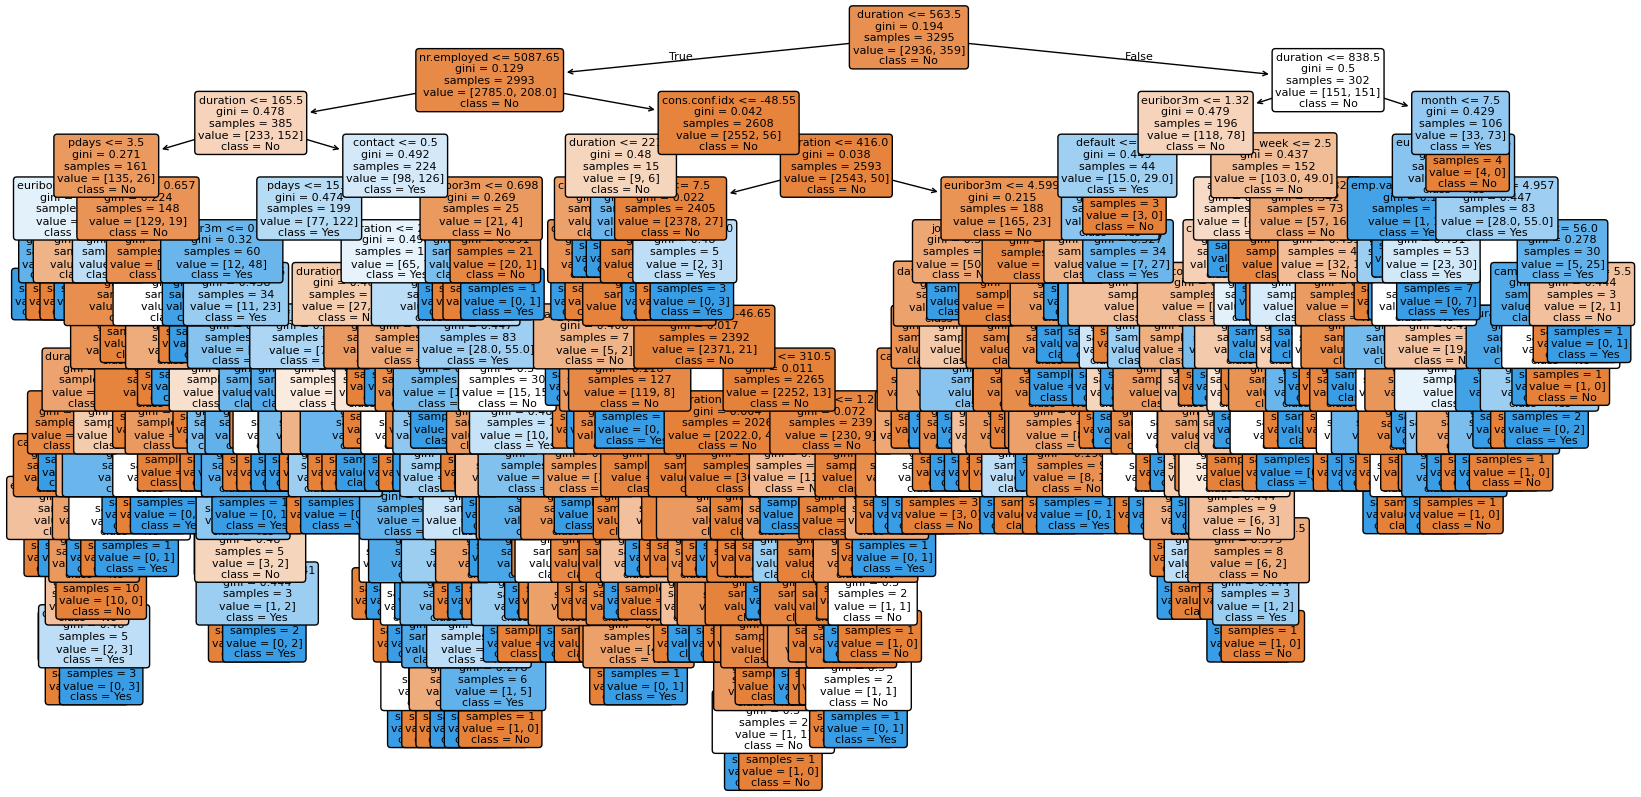

In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

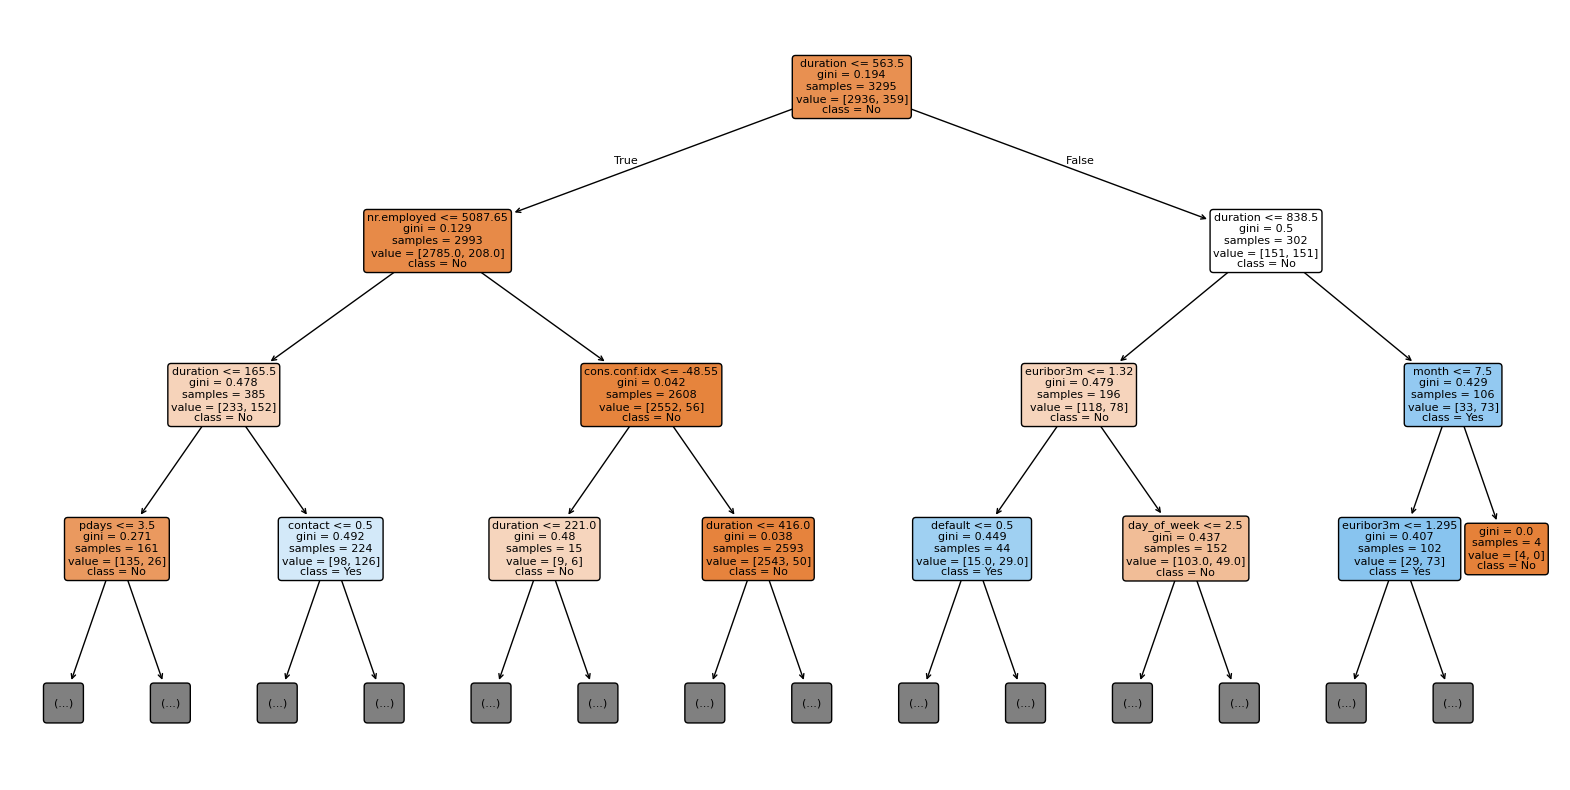

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3,      # Sirf first 3 levels
    fontsize=8
)

plt.show()